In [20]:
# Import libraries for analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import libraries for preprocessing
from sklearn.impute import SimpleImputer  # Handling null values
from sklearn.preprocessing import LabelEncoder  # Encoding categorical data
from sklearn.preprocessing import StandardScaler  # Rescaling numeric values
from sklearn.model_selection import train_test_split  # Splitting data into train and test

In [21]:
df = pd.read_csv('./1553768847-housing.csv')

In [22]:
df.sample(100)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
3343,-122.64,38.71,20,531,126.0,231,96,2.6250,INLAND,89600
4408,-118.23,34.09,49,1638,456.0,1500,430,2.6923,<1H OCEAN,150000
3089,-118.33,35.64,15,2966,669.0,1007,465,1.5667,INLAND,72500
12620,-121.53,38.50,17,3087,477.0,1365,495,6.4667,INLAND,216800
18201,-122.02,37.39,35,2297,497.0,1428,497,4.7431,<1H OCEAN,239700
...,...,...,...,...,...,...,...,...,...,...
19923,-119.34,36.32,6,3266,604.0,1769,580,3.1574,INLAND,89200
8425,-118.34,33.92,29,1475,349.0,965,370,3.3558,<1H OCEAN,199600
8062,-118.20,33.83,35,3737,613.0,1305,583,7.2096,NEAR OCEAN,490300
10936,-117.90,33.74,24,1435,494.0,3171,504,3.0833,<1H OCEAN,151700


In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   ocean_proximity     20640 non-null  str    
 9   median_house_value  20640 non-null  int64  
dtypes: float64(4), int64(5), str(1)
memory usage: 1.6 MB


## **Data Preprocessing**

#### **Hundling Null Values**
https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html

In [24]:
# Create a SimpleImputer instance
imputer = SimpleImputer(strategy='mean')  # You can use 'mean', 'median', 'most_frequent', or a constant value

print(imputer)

# Fit the imputer on the data and transform it
df['total_bedrooms'] = imputer.fit_transform(df[['total_bedrooms']])

SimpleImputer()


In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20640 non-null  float64
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   ocean_proximity     20640 non-null  str    
 9   median_house_value  20640 non-null  int64  
dtypes: float64(4), int64(5), str(1)
memory usage: 1.6 MB


#### **Handling Duplicated Values**

In [26]:
# Check for duplicates in the entire DataFrame
duplicates = df.duplicated()
duplicates.value_counts()

False    20640
Name: count, dtype: int64

#### **Handling Outliers Values**

**How to check outliers?**

1. **Z-Score Method:**
    - The Z-score measures how many standard deviations a data point is from the mean. 
    - Data points with a high absolute Z-score are considered outliers.

    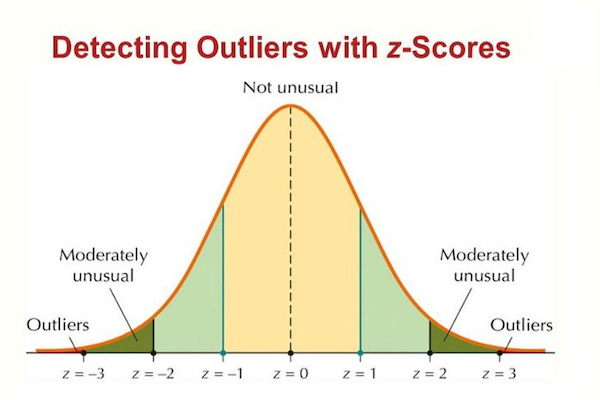

In [27]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,419.266592,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,297.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,438.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,643.250000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [28]:
columns = list(df.columns)[2:]
columns.remove('ocean_proximity')
columns

['housing_median_age',
 'total_rooms',
 'total_bedrooms',
 'population',
 'households',
 'median_income',
 'median_house_value']

In [29]:
from scipy import stats

for column_name in columns:
    z_scores = stats.zscore(df[f'{column_name}'])
    outliers = (np.abs(z_scores) > 3)

    print(outliers.value_counts())
    print('=' * 20)

AttributeError: 'numpy.ndarray' object has no attribute 'value_counts'

2. **IQR (Interquartile Range)**
    - The Interquartile Range (IQR) is a measure of statistical dispersion that describes the range between the first quartile (Q1) and the third quartile (Q3) in a dataset. The IQR is calculated as follows: IQR=Q3−Q1

    To detect outliers using the IQR method, you typically follow these steps:

    - **Calculate Quartiles:**
        Sort the dataset in ascending order.
        Find the first quartile (Q1) and third quartile (Q3).
        Calculate the interquartile range (IQR) as IQR=Q3−Q1.

    - **Define Outlier Boundaries:**
        Set lower and upper boundaries for outliers using the formula:
        Lower Bound: Q1−1.5×IQR
        Upper Bound: Q3+1.5×IQR

    - **Identify Outliers:**
        Any data point outside the defined boundaries is considered an outlier.
        The 1.5 multiplier is a commonly used constant, but you can adjust it based on the desired sensitivity to outliers. A higher multiplier makes the method less sensitive, while a lower multiplier makes it more sensitive.

In [ ]:
for column_name in columns:
        
    Q1 = df[f'{column_name}'].quantile(0.25)
    Q3 = df[f'{column_name}'].quantile(0.75)
    IQR = Q3 - Q1

    outliers = ((df[f'{column_name}'] < (Q1 - 1.5 * IQR)) | (df[f'{column_name}'] > (Q3 + 1.5 * IQR)))
    print(outliers.value_counts())
    print('=' * 20)


housing_median_age
False    20640
Name: count, dtype: int64
total_rooms
False    19353
True      1287
Name: count, dtype: int64
total_bedrooms
False    19334
True      1306
Name: count, dtype: int64
population
False    19444
True      1196
Name: count, dtype: int64
households
False    19420
True      1220
Name: count, dtype: int64
median_income
False    19959
True       681
Name: count, dtype: int64
median_house_value
False    19569
True      1071
Name: count, dtype: int64


3. **Boxplot**
    - A boxplot typically consists of a rectangular "box" and two "whiskers" extending from the box. 
    - The box represents the interquartile range (IQR), which contains the middle 50% of the data.
    - The line inside the box represents the median (50th percentile).
    - Whiskers extend from the box to the minimum and maximum values within a certain range.
    - Outliers are individual data points plotted outside the whiskers.

    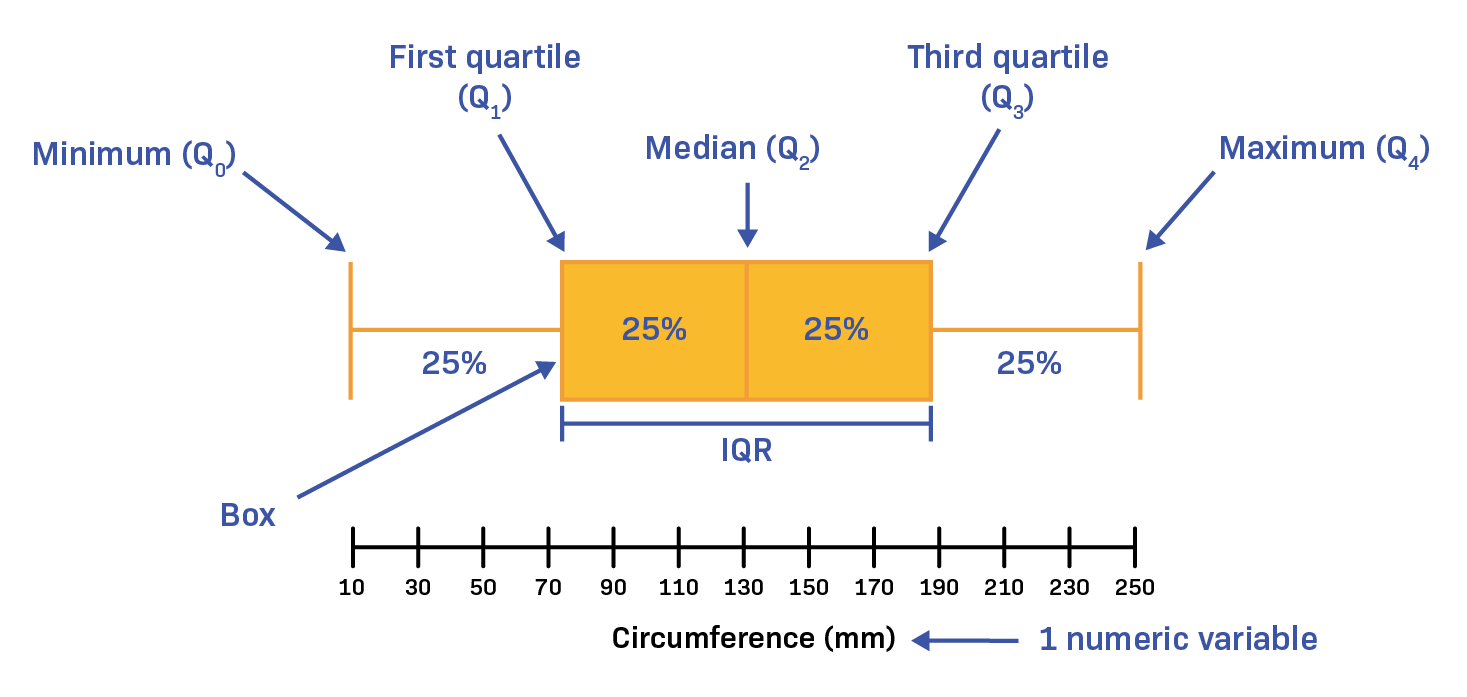

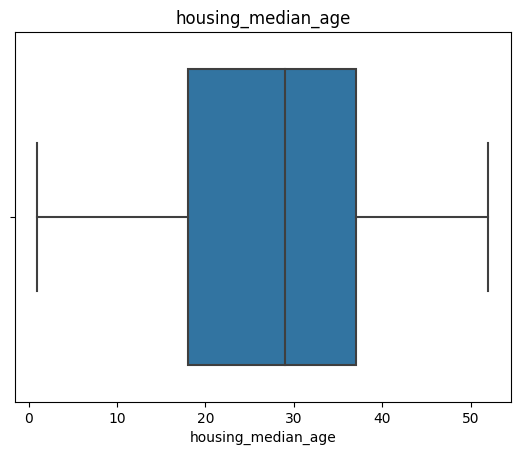

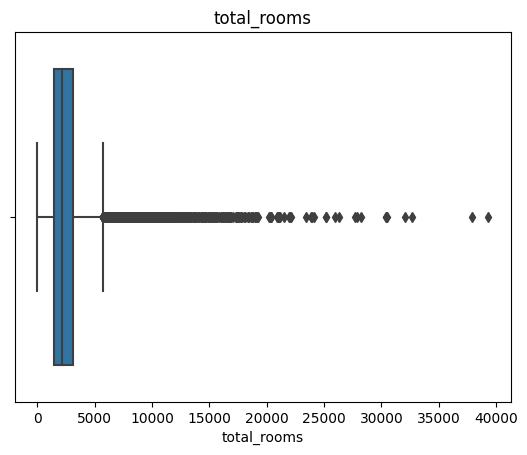

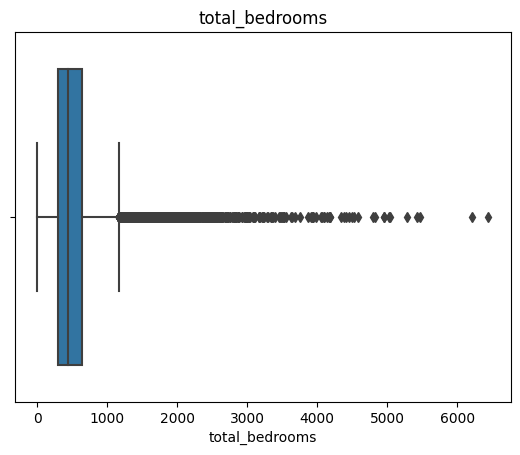

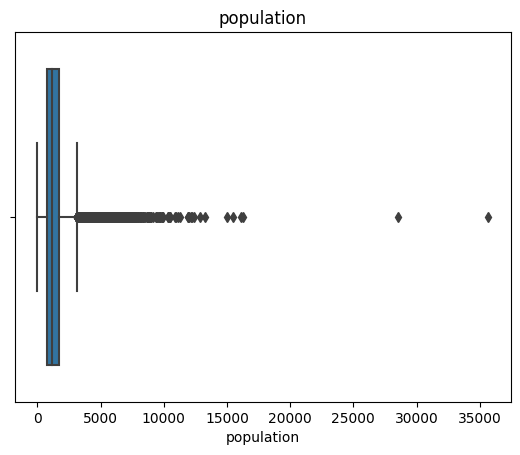

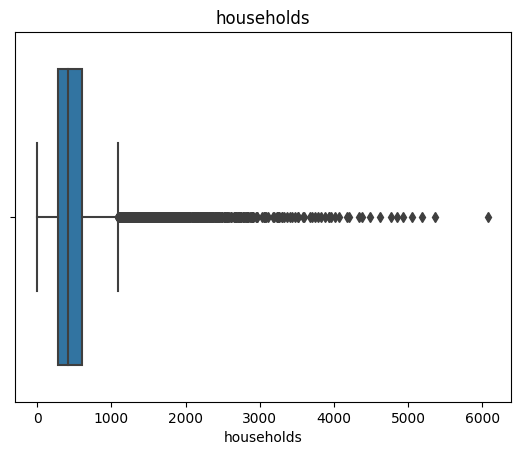

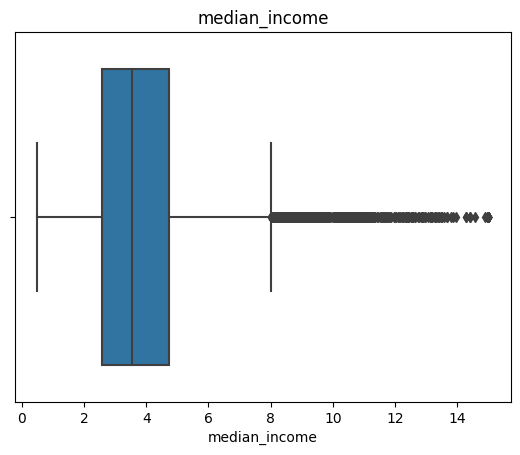

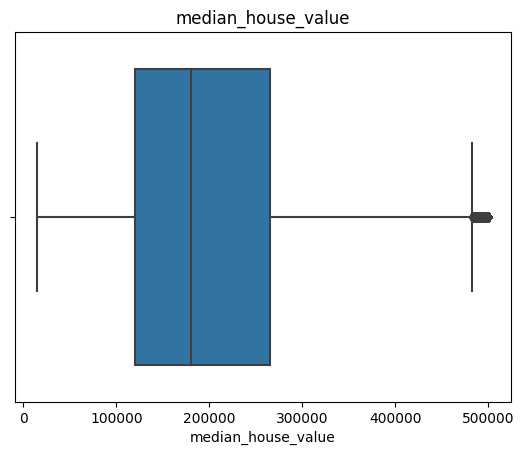

In [ ]:
for column_name in columns:
    sns.boxplot(x=df[f'{column_name}'])
    plt.title(f'{column_name}')
    plt.show()

4. **Percentile-based Thresholds**
- Detecting outliers using percentile-based thresholds involves identifying data points that fall outside a specified percentage range of the data distribution. 
- The key idea is to set thresholds based on percentiles, such as the minimum and maximum values within a certain range. This method is flexible and can be adapted to various scenarios based on the desired percentage range.

In [ ]:
# Choose percentile range (e.g., 5th and 95th percentiles)
lower_percentile = 5
upper_percentile = 95

for column_name in columns:
    # Calculate percentile values
    lower_bound = np.percentile(df[f'{column_name}'], lower_percentile)
    upper_bound = np.percentile(df[f'{column_name}'], upper_percentile)

    # Identify potential outliers
    outliers = (df[f'{column_name}'] < lower_bound) | (df[f'{column_name}'] > upper_bound)

    print(f"{lower_percentile}th Percentile:", lower_bound)
    print(f"{upper_percentile}th Percentile:", upper_bound)
    print(outliers.value_counts())
    print('=' * 20)

5th Percentile: 8.0
95th Percentile: 52.0
housing_median_age
False    19746
True       894
Name: count, dtype: int64
5th Percentile: 620.95
95th Percentile: 6213.199999999997
total_rooms
False    18576
True      2064
Name: count, dtype: int64
5th Percentile: 138.0
95th Percentile: 1271.0
total_bedrooms
False    18581
True      2059
Name: count, dtype: int64
5th Percentile: 348.0
95th Percentile: 3288.0
population
False    18579
True      2061
Name: count, dtype: int64
5th Percentile: 125.0
95th Percentile: 1162.0
households
False    18580
True      2060
Name: count, dtype: int64
5th Percentile: 1.60057
95th Percentile: 7.300305
median_income
False    18576
True      2064
Name: count, dtype: int64
5th Percentile: 66200.0
95th Percentile: 489809.9999999999
median_house_value
False    18577
True      2063
Name: count, dtype: int64


#### **Data Encoding**

**Label Encoding:**

- Label encoding is a technique for converting categorical data into numerical data.
- It assigns a unique integer (label) to each category or class in a categorical variable.
- Often used for categorical variables with ordinal relationships, where the order of categories matters.

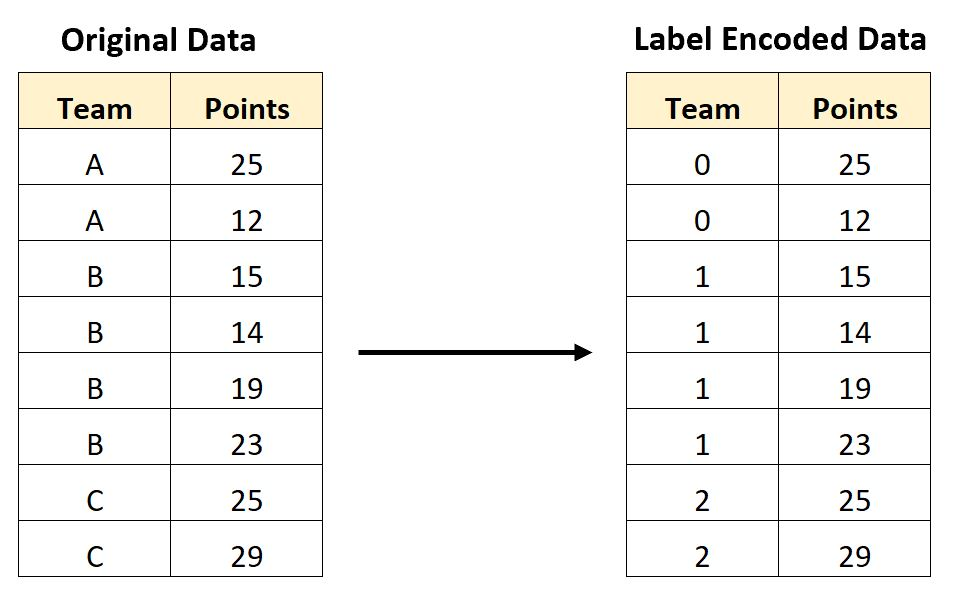

In [ ]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['ocean_proximity'] = encoder.fit_transform(df['ocean_proximity'])

In [ ]:
df.head(1)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,3,452600


**One-Hot Encoding:**

- One-hot encoding is used to represent categorical variables as binary vectors.
- It creates a new binary feature (0 or 1) for each category in the original variable.
- Each observation gets a 1 in the corresponding category and 0s in all other categories.
- Useful for categorical variables without ordinal relationships, as it avoids introducing misleading ordinal information.

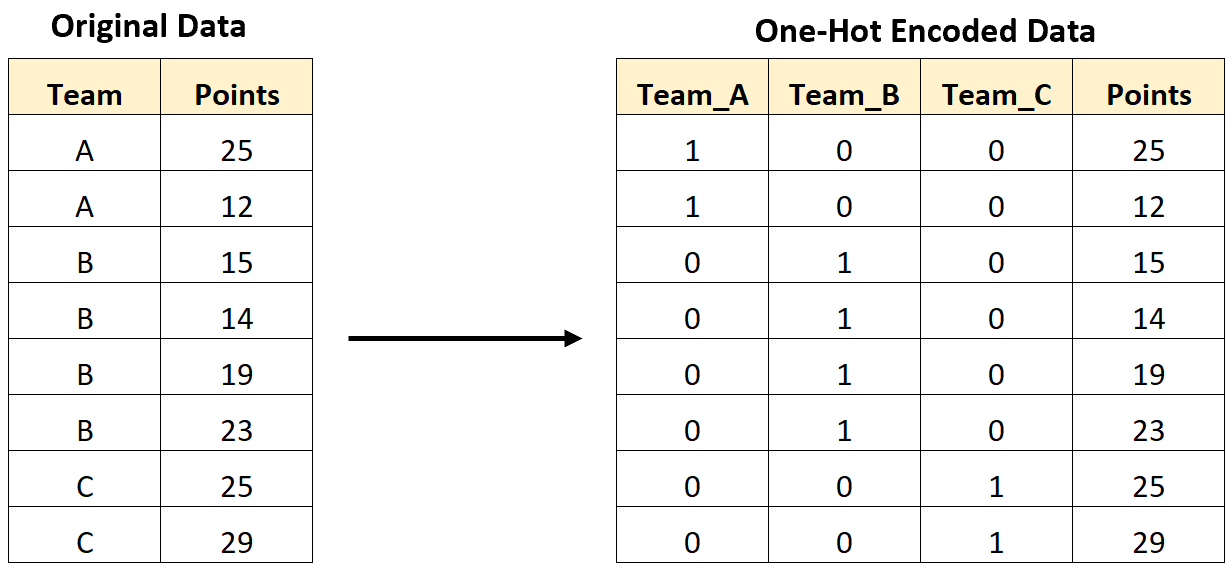

In [ ]:
# from sklearn.preprocessing import OneHotEncoder
# encoder = OneHotEncoder()
# X = onehotencoder.fit_transform(data[column].values.reshape(-1,1)).toarray()
# dfOneHot = pd.DataFrame(X, columns = [str(int(i)) for i in range(X.shape[1])]) 
# new_df = pd.concat([df, dfOneHot], axis=1)
# df= df.drop(['Country'], axis=1) 

#### **Data Scaling**

**Min-Max Scaling (Normalization):**

- Scales the data to a specific range, often [0, 1].
- Useful when features have a known upper and lower bound and you want to preserve the relationship between data points.

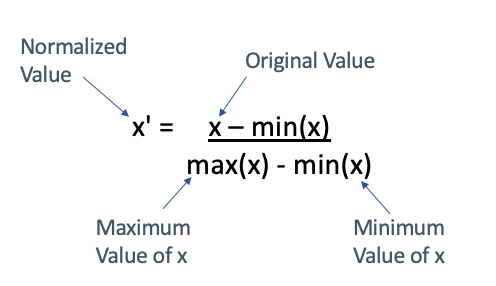

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df = scaler.fit_transform(df)

In [ ]:
df

array([[0.21115538, 0.5674814 , 0.78431373, ..., 0.53966842, 0.75      ,
        0.90226638],
       [0.21215139, 0.565356  , 0.39215686, ..., 0.53802706, 0.75      ,
        0.70824656],
       [0.21015936, 0.5642933 , 1.        , ..., 0.46602805, 0.75      ,
        0.69505074],
       ...,
       [0.31175299, 0.73219979, 0.31372549, ..., 0.08276438, 0.25      ,
        0.15938285],
       [0.30179283, 0.73219979, 0.33333333, ..., 0.09429525, 0.25      ,
        0.14371281],
       [0.30976096, 0.72582359, 0.29411765, ..., 0.13025338, 0.25      ,
        0.15340349]])

**Standardization (Z-score Scaling):**

- Standardizes data to have a mean (average) of 0 and a standard deviation of 1.
- It is suitable when the data has a Gaussian (normal) distribution or when you want to remove the mean and have unit variance.

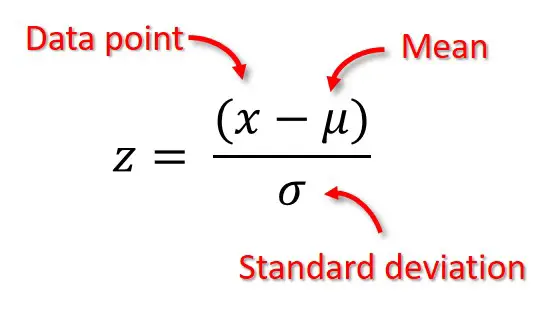

In [ ]:
# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()
# df = scaler.fit_transform(df)

#### **Data Splitting**

**Train-Test Split:**

- Split the dataset into two parts: a training set and a test set.
- The training set is used to train the model, and the test set is used to evaluate its performance.
- Common split ratios are 70-30, 80-20, or 90-10, depending on the dataset size.

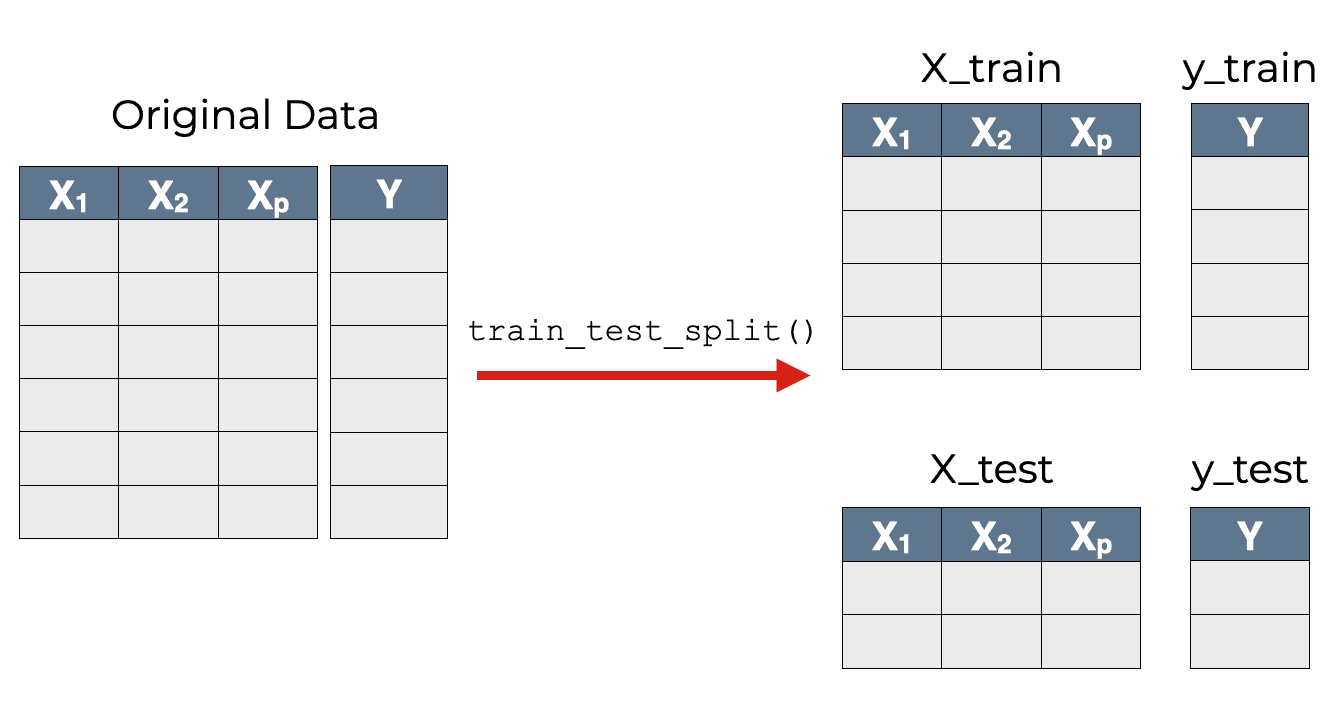

In [ ]:
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(df, test_size=0.2, shuffle=True, random_state=42)

**K-Fold Cross-Validation:**

- Divide the dataset into "k" equal-sized folds or subsets.
- Train and validate the model k times, each time using a different fold as the validation set and the remaining folds as the training set.
- Calculate performance metrics by averaging the results from all iterations.
- Common values for "k" are 5 and 10, but it can vary depending on the dataset size.

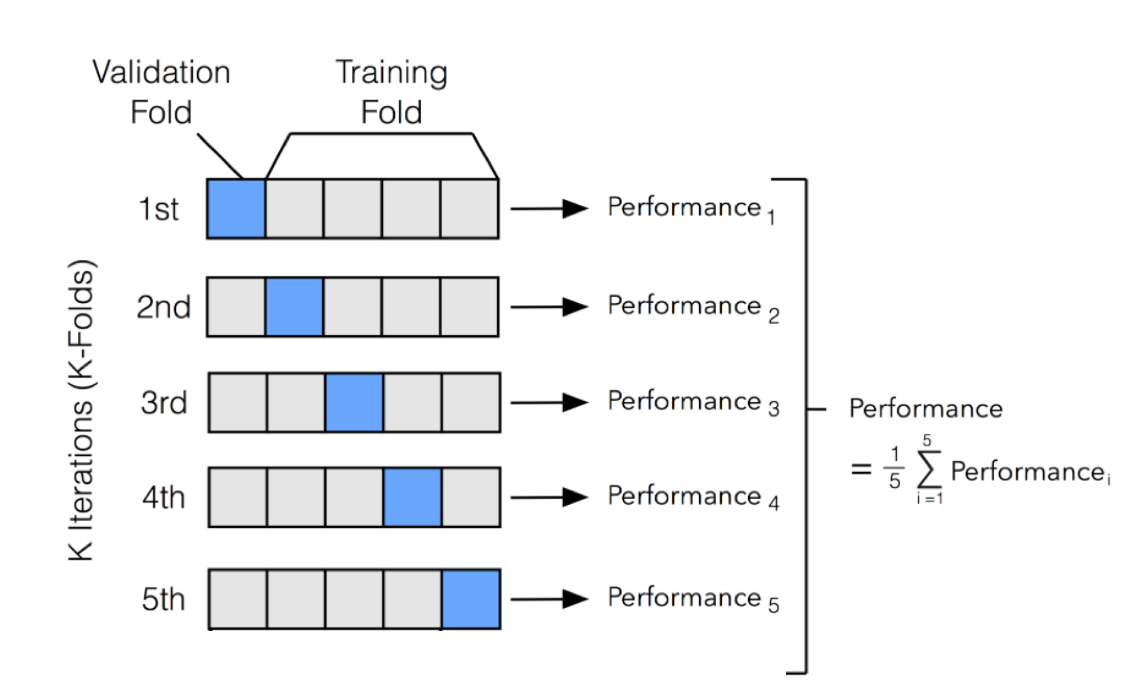

In [ ]:
# from sklearn.model_selection import cross_val_score, KFold

# num_folds = 5
# kfold = KFold(n_splits=num_folds, shuffle=True, random_state=42)
# cv_results = cross_val_score(model, X, y, cv=kfold, scoring='accuracy')

# for i, accuracy in enumerate(cv_results, 1):
#     print(accuracy)

# print(cv_results.mean())